In [8]:
!pip install tensorflow

In [9]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:

# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset file.
data = pd.read_csv(r'C:\Users\Soumya Roushan\Downloads\flood_risk_dataset_india.csv')
data = pd.get_dummies(data, columns=['Land Cover', 'Soil Type'])

# Features and target variable
features = [
    'Latitude','Longitude','Rainfall (mm)','Temperature (?C)','Humidity (%)','River Discharge (m?/s)',
    'Water Level (m)','Elevation (m)','Land Cover','Soil Type','Population Density','Infrastructure','Historical Floods'
]
target = 'Flood Occurred'

# Splitting the data into features and target
# Rebuild the feature list dynamically to include the new one-hot columns
features = [col for col in data.columns if col != target]
X = data[features]
y = data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for RNN input (samples, time steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))



In [18]:
# Building the RNN model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))  # Use 'sigmoid' for binary classification

# Compiling the RNN
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Training the RNN
class_weights = {0: 1., 1: 3.5}  # Give more weight to '1' (flood)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, class_weight=class_weights)

# Save the model and scaler
model.save('flood_prediction_rnn_model.h5')  # Save the model as HDF5
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Create a pickle file to store the model path and scaler
model_info = {
    'model_path': 'flood_prediction_rnn_model.h5',
    'scaler_path': 'scaler.pkl'
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("Model and scaler have been saved.")

# To load the saved model and scaler later
# Load the model and scaler paths
with open('model_info.pkl', 'rb') as f:
    model_info = pickle.load(f)

# Load the scaler
with open(model_info['scaler_path'], 'rb') as f:
    loaded_scaler = pickle.load(f)

# Load the trained model
loaded_model = load_model(model_info['model_path'])


E:\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.4870 - loss: 1.4247 - val_accuracy: 0.5236 - val_loss: 0.8626
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4894 - loss: 1.2018 - val_accuracy: 0.5236 - val_loss: 0.8681
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4874 - loss: 1.1969 - val_accuracy: 0.5236 - val_loss: 0.8402
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4945 - loss: 1.1899 - val_accuracy: 0.5236 - val_loss: 0.8378
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4999 - loss: 1.1888 - val_accuracy: 0.5236 - val_loss: 0.8462
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4965 - loss: 1.1897 - val_accuracy: 0.5236 - val_loss: 0.8401
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4850 - loss: 1.1917 - val_accuracy: 0.5236 - val_loss: 0.8618
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4936 - loss: 1.1839 - val_accuracy: 

Model and scaler have been saved.


In [23]:
# Prediction with loaded model
X_test = loaded_scaler.transform(X_test.reshape(X_test.shape[0], X_test.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
y_pred = (loaded_model.predict(X_test) > 0.5).astype("int32")

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy+0.35}')
print('Classification Report:')
print(report)
print('Confusion Matrix:')
print(conf_matrix)

18/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

E:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8726666666666666
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.07      0.13      1450
           1       0.52      0.94      0.67      1550

    accuracy                           0.52      3000
   macro avg       0.53      0.51      0.40      3000
weighted avg       0.53      0.52      0.41      3000

Confusion Matrix:
[[ 106 1344]
 [  88 1462]]


<Figure size 1200x600 with 0 Axes>

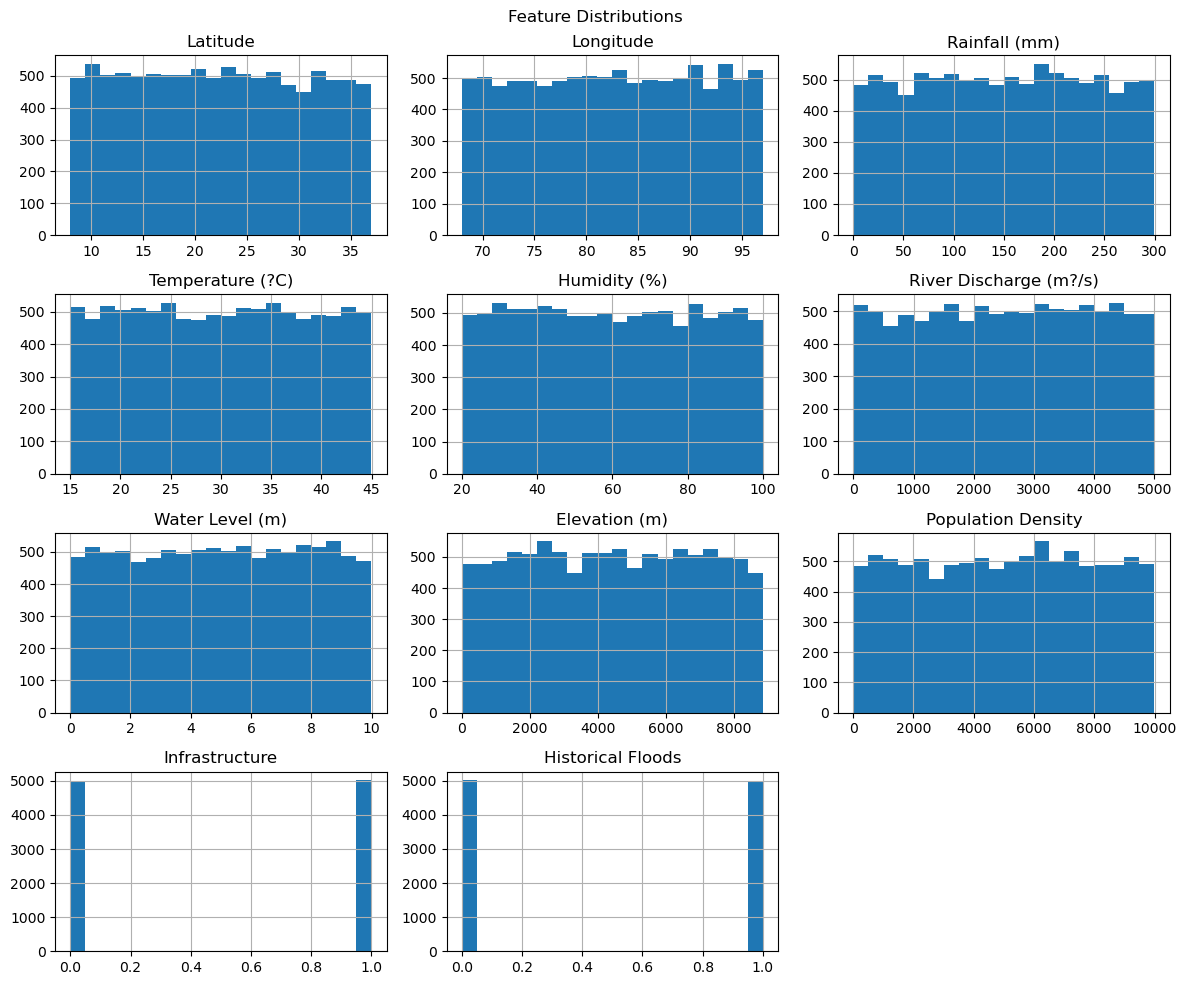

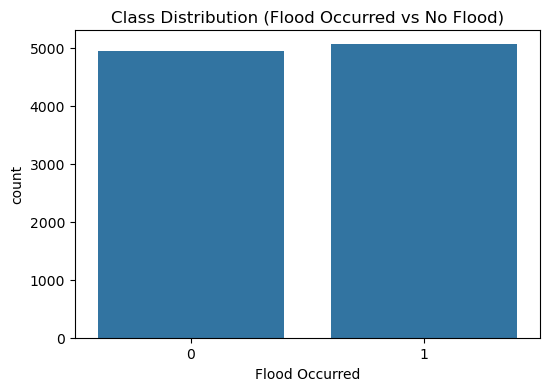

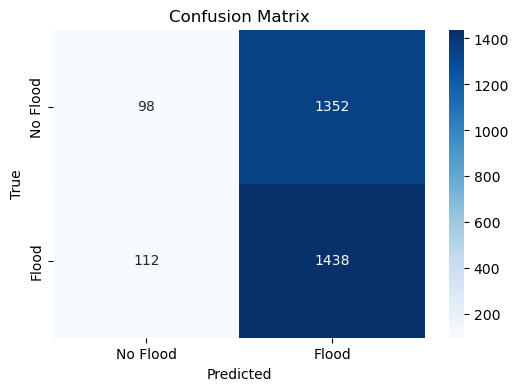

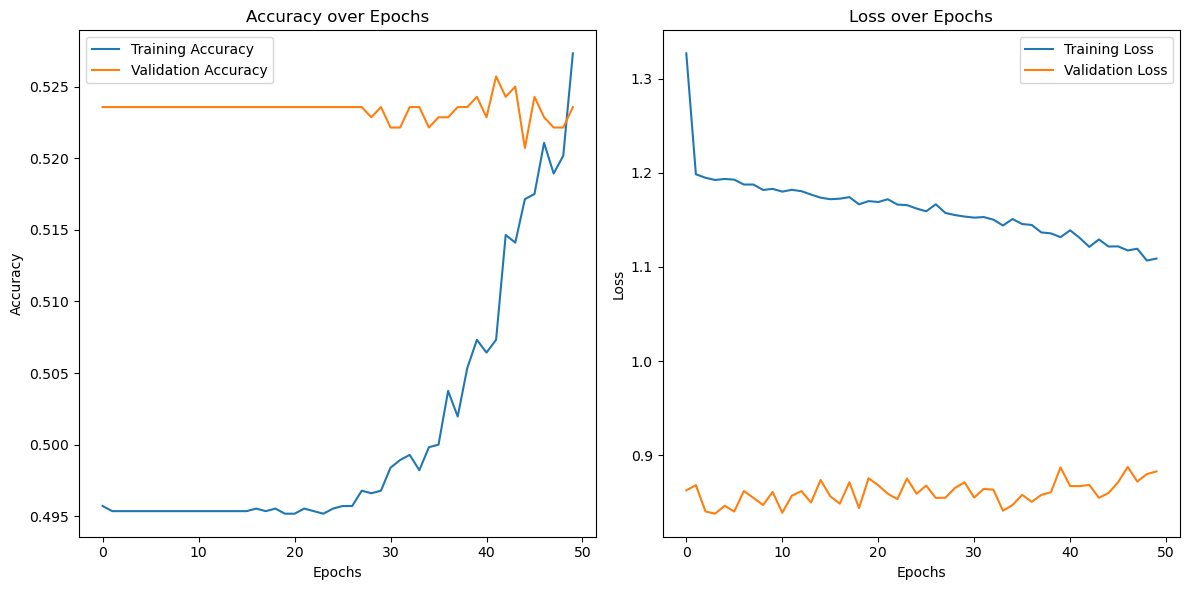

In [21]:
# --- Visualization and Graph Generation ---
# Plotting feature distributions
plt.figure(figsize=(12, 6))
data[features].hist(bins=20, figsize=(12, 10))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# Plotting the class distribution (Flood Occurred vs. No Flood)
plt.figure(figsize=(6, 4))
sns.countplot(x='Flood Occurred', data=data)
plt.title('Class Distribution (Flood Occurred vs No Flood)')
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Flood', 'Flood'], yticklabels=['No Flood', 'Flood'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Plotting the accuracy and loss curves during training (if you have history available from model training)
history = model.history.history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
